In [5]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [6]:
from importlib import reload
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [7]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/extra/velocity")
FIG_SAVE_PATH.mkdir(exist_ok=True, parents=True)

In [8]:
from GridMaze.analysis.movement import velocity as vel

In [9]:
reload(vel)
pop_velocity_tuning = vel.get_population_velocity_summary(verbose=False)

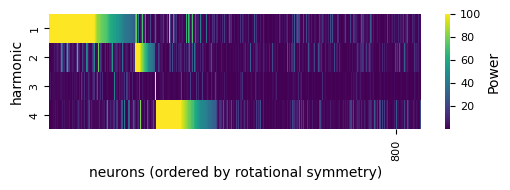

In [10]:
reload(vel)
f, ax = plt.subplots(1, 1, figsize=(6, 1.5))
vel.plot_velocity_population_symmetry_heatmap(pop_velocity_tuning, ax=ax)
f.savefig(FIG_SAVE_PATH / "population_velocity_tuning.pdf")

In [11]:
from GridMaze.analysis.core import get_clusters as gc

# look at some illustrative single cells
example_clusters = [
    "m3.2022-07-19.maze_cluster0",  # velocity
    "m6.2022-07-05.maze_cluster65",  # velocity
    "m6.2022-07-04.maze_cluster4",  # velocity
    "m3.2022-07-11.maze_cluster63",  # 2way sym
    "m3.2022-07-15.maze_cluster135",  # 4sym on axis
    "m2.2022-06-28.maze_cluster10",  # 4way off axis
    "m2.2022-07-19.maze_cluster140",  # speed ring
    "m4.2022-07-01.maze_cluster59",  # speed
]

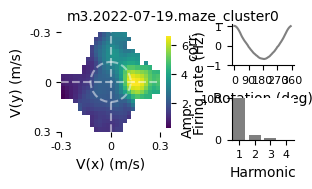

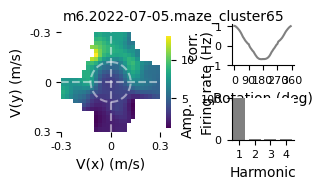

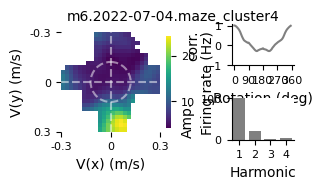

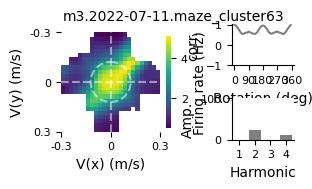

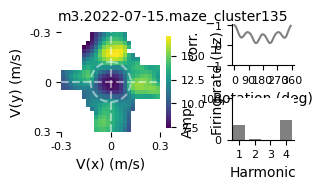

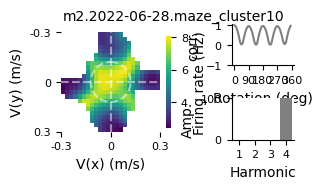

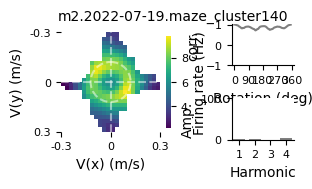

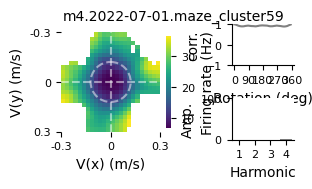

In [17]:
from numpy import save

from GridMaze.analysis.cluster_tuning import movement

reload(movement)
reload(gc)
for cuID in example_clusters:
    Cluster = gc.get_cluster(cluster_unique_ID=cuID)
    fig = plt.figure(figsize=(3, 1.5), clear=True)
    gsc = GridSpec(2, 2, figure=fig, width_ratios=[2, 1], wspace=0.5, hspace=0.8)
    ax1 = fig.add_subplot(gsc[0:2, 0])  # v heatmap
    ax2 = fig.add_subplot(gsc[0, 1])  # rot corr
    ax3 = fig.add_subplot(gsc[1, 1])  # harmonics
    Cluster.plot_tuning(
        feature="velocity", feature_kwargs={"with_symmetry": True, "navigation_only": True}, ax=(ax1, ax2, ax3)
    )
    fig.suptitle(cuID)
    save_path = FIG_SAVE_PATH / f"{cuID}_velocity_tuning.pdf"
    fig.savefig(save_path)

In [13]:
# illustrate harmonics idea with one cell
from GridMaze.analysis.cluster_tuning import movement as mv

Cluster = gc.get_cluster(cluster_unique_ID=example_clusters[0])
velocity_tuning = Cluster.load_tuning_data(
    feature="velocity", feature_kwargs={"with_symmetry": True, "navigation_only": True}
)

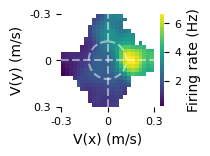

In [14]:
# plot heatmap
f, ax = plt.subplots(figsize=(1.5, 1.5))
mv.plot_velocity_tuning(velocity_tuning, ax=ax)
f.savefig(FIG_SAVE_PATH / f"{example_clusters[0]}_velocity_tuning_heatmap.pdf")

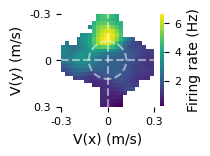

In [15]:
# plot rotated heatmap
import pandas as pd

angle = 90
rotated_arr, _ = mv.rotate_with_nan(velocity_tuning.values, angle_deg=angle)
velocity_rotated = pd.DataFrame(rotated_arr, index=velocity_tuning.index, columns=velocity_tuning.columns)
f, ax = plt.subplots(figsize=(1.5, 1.5))
mv.plot_velocity_tuning(velocity_rotated, ax=ax)
f.savefig(FIG_SAVE_PATH / f"{example_clusters[0]}_velocity_tuning_rotated.pdf")

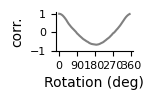

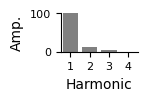

In [18]:
rot_corrs, angles = mv.get_rotational_autocorr(velocity_tuning)
f, ax = plt.subplots(1, 1, figsize=(1, 0.5))
mv.plot_rotational_autocorr(rot_corrs, angles, ax=ax)
f.savefig(FIG_SAVE_PATH / f"{example_clusters[0]}_velocity_tuning_rot_autocorr.pdf")
f, ax = plt.subplots(1, 1, figsize=(1, 0.5))
power = mv.rotational_spectrum(rot_corrs)
mv.plot_rotational_spectrum(power, ax=ax)
f.savefig(FIG_SAVE_PATH / f"{example_clusters[0]}_velocity_tuning_rot_spectrum.pdf")